In [7]:

import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display

ALPHA = 0.05


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/closest_contacts_1mm.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/closest_contacts_1mm.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/closest_contacts_1mm.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/closest_contacts_1mm.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/closest_contacts_1mm.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/closest_contacts_1mm.csv')
df6['Condition'] = 'SI Starved-Starved'


def complete_counts(df, condition_order):
    interaction_order = list(pd.unique(df['Closest Interaction Type'].dropna()))
    files = df[['Condition', 'file']].drop_duplicates()
    full = (
        files.assign(_key=1)
        .merge(pd.DataFrame({'Closest Interaction Type': interaction_order, '_key': 1}), on='_key')
        .drop(columns='_key')
    )
    counts = (
        df.groupby(['Condition', 'file', 'Closest Interaction Type'])
        .size()
        .reset_index(name='count')
    )
    grouped = full.merge(counts, how='left').fillna({'count': 0})
    grouped['count'] = grouped['count'].astype(int)
    grouped['Condition'] = pd.Categorical(grouped['Condition'], condition_order, ordered=True)
    grouped['Closest Interaction Type'] = pd.Categorical(grouped['Closest Interaction Type'], interaction_order, ordered=True)
    return grouped, interaction_order


def stars(p):
    if p < 0.0001:
        return '****'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def contact_stats(grouped, condition_order, interaction_order):
    omnibus_rows = []
    pairwise_rows = []

    for interaction in interaction_order:
        data = grouped[grouped['Closest Interaction Type'] == interaction]
        samples = [data.loc[data['Condition'] == condition, 'count'] for condition in condition_order]

        if len(condition_order) > 2:
            all_counts = pd.concat(samples)
            p_omnibus = 1.0 if all_counts.nunique() <= 1 else kruskal(*samples).pvalue
            omnibus_rows.append({
                'Closest Interaction Type': interaction,
                'test': 'Kruskal-Wallis',
                'p': p_omnibus,
            })

        for condition_a, condition_b in combinations(condition_order, 2):
            a = data.loc[data['Condition'] == condition_a, 'count']
            b = data.loc[data['Condition'] == condition_b, 'count']
            p_pairwise = 1.0 if pd.concat([a, b]).nunique() <= 1 else mannwhitneyu(a, b, alternative='two-sided').pvalue
            pairwise_rows.append({
                'Closest Interaction Type': interaction,
                'condition_a': condition_a,
                'condition_b': condition_b,
                'test': 'Mann-Whitney U',
                'p': p_pairwise,
            })

    pairwise = pd.DataFrame(pairwise_rows)
    pairwise['p_adj'] = multipletests(pairwise['p'], method='fdr_bh')[1]
    pairwise['stars'] = pairwise['p_adj'].apply(stars)
    omnibus = pd.DataFrame(omnibus_rows)
    return pairwise, omnibus


def add_sig_stars(ax, pairwise, condition_order, interaction_order):
    significant = pairwise[pairwise['p_adj'] < ALPHA]
    if significant.empty:
        return

    bar_containers = [c for c in ax.containers if hasattr(c, 'patches') and len(c.patches)]
    bar = {}
    for condition_i, container in enumerate(bar_containers[:len(condition_order)]):
        for interaction_i, patch in enumerate(container.patches[:len(interaction_order)]):
            bar[(condition_order[condition_i], interaction_order[interaction_i])] = patch

    y_step = max([patch.get_height() for patch in bar.values()] + [1]) * 0.08
    y_step = max(y_step, 0.5)
    levels = {interaction: 0 for interaction in interaction_order}

    for _, row in significant.sort_values(['Closest Interaction Type', 'p_adj']).iterrows():
        interaction = row['Closest Interaction Type']
        patch_a = bar[(row['condition_a'], interaction)]
        patch_b = bar[(row['condition_b'], interaction)]
        x1 = patch_a.get_x() + patch_a.get_width() / 2
        x2 = patch_b.get_x() + patch_b.get_width() / 2
        y = max(patch_a.get_height(), patch_b.get_height()) + y_step * (levels[interaction] + 1)
        levels[interaction] += 1

        ax.plot([x1, x1, x2, x2], [y, y + y_step * 0.25, y + y_step * 0.25, y], color='black', linewidth=1)
        ax.text((x1 + x2) / 2, y + y_step * 0.3, row['stars'], ha='center', va='bottom', color='black')

    ax.set_ylim(top=max(ax.get_ylim()[1], max(p.get_height() for p in bar.values()) + y_step * (max(levels.values()) + 2)))


def plot_contact_counts(dataframes, condition_order, palette, title):
    df = pd.concat(dataframes, ignore_index=True)
    grouped, interaction_order = complete_counts(df, condition_order)
    pairwise, omnibus = contact_stats(grouped, condition_order, interaction_order)

    plt.figure(figsize=(10, 4))
    ax = sns.barplot(
        data=grouped,
        x='Closest Interaction Type',
        y='count',
        hue='Condition',
        order=interaction_order,
        hue_order=condition_order,
        errorbar='sd',
        palette=palette,
    )
    add_sig_stars(ax, pairwise, condition_order, interaction_order)

    ax.set_title(title)
    ax.set_ylabel('Count per file')
    ax.set_xlabel('Closest Interaction Type')
    plt.xticks(rotation=45, ha='right')
    ax.set_ylim(0, None)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    display(pairwise.sort_values(['Closest Interaction Type', 'p_adj']))
    if not omnibus.empty:
        display(omnibus)

    return grouped, pairwise, omnibus


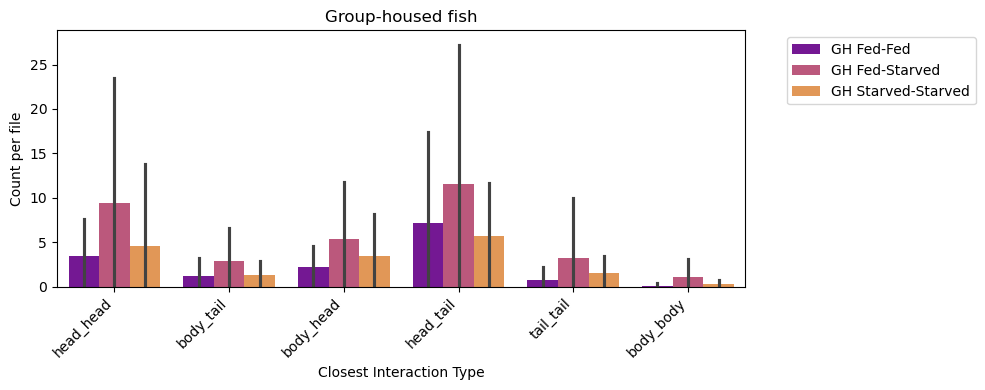

,Closest Interaction Type,condition_a,condition_b,test,p,p_adj,stars
15,body_body,GH Fed-Fed,GH Fed-Starved,Mann-Whitney U,0.003185,0.057334,n.s.
17,body_body,GH Fed-Starved,GH Starved-Starved,Mann-Whitney U,0.061846,0.222646,n.s.
16,body_body,GH Fed-Fed,GH Starved-Starved,Mann-Whitney U,0.244355,0.405693,n.s.
6,body_head,GH Fed-Fed,GH Fed-Starved,Mann-Whitney U,0.079223,0.233102,n.s.
8,body_head,GH Fed-Starved,GH Starved-Starved,Mann-Whitney U,0.194854,0.389708,n.s.
7,body_head,GH Fed-Fed,GH Starved-Starved,Mann-Whitney U,0.791177,0.890074,n.s.
3,body_tail,GH Fed-Fed,GH Fed-Starved,Mann-Whitney U,0.046065,0.207293,n.s.
5,body_tail,GH Fed-Starved,GH Starved-Starved,Mann-Whitney U,0.247923,0.405693,n.s.
4,body_tail,GH Fed-Fed,GH Starved-Starved,Mann-Whitney U,0.328899,0.490834,n.s.
2,head_head,GH Fed-Starved,GH Starved-Starved,Mann-Whitney U,0.090651,0.233102,n.s.


,Closest Interaction Type,test,p
0,head_head,Kruskal-Wallis,0.164922
1,body_tail,Kruskal-Wallis,0.110812
2,body_head,Kruskal-Wallis,0.176124
3,head_tail,Kruskal-Wallis,0.568734
4,tail_tail,Kruskal-Wallis,0.058565
5,body_body,Kruskal-Wallis,0.006838


In [8]:
gh_grouped, gh_pairwise, gh_omnibus = plot_contact_counts(
    [df1, df2, df3],
    condition_order=['GH Fed-Fed', 'GH Fed-Starved', 'GH Starved-Starved'],
    palette='plasma',
    title='Group-housed fish'
)


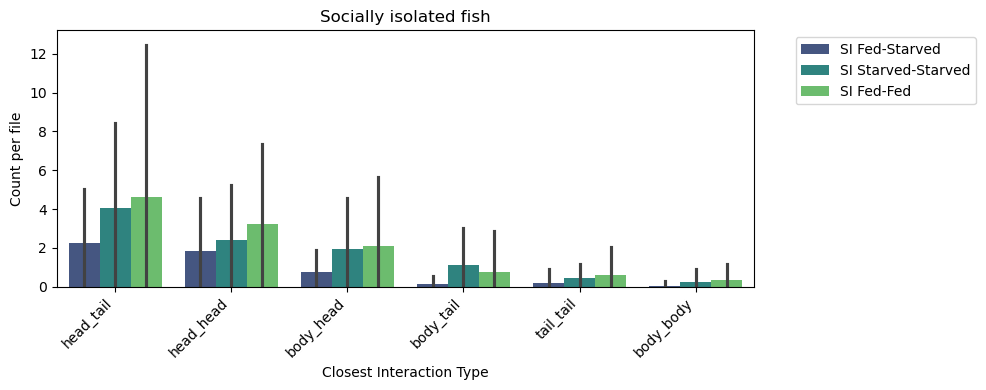

,Closest Interaction Type,condition_a,condition_b,test,p,p_adj,stars
16,body_body,SI Fed-Starved,SI Fed-Fed,Mann-Whitney U,0.152602,0.549368,n.s.
15,body_body,SI Fed-Starved,SI Starved-Starved,Mann-Whitney U,0.285077,0.616712,n.s.
17,body_body,SI Starved-Starved,SI Fed-Fed,Mann-Whitney U,0.724356,0.766965,n.s.
6,body_head,SI Fed-Starved,SI Starved-Starved,Mann-Whitney U,0.148693,0.549368,n.s.
7,body_head,SI Fed-Starved,SI Fed-Fed,Mann-Whitney U,0.067114,0.549368,n.s.
8,body_head,SI Starved-Starved,SI Fed-Fed,Mann-Whitney U,0.941316,0.941316,n.s.
9,body_tail,SI Fed-Starved,SI Starved-Starved,Mann-Whitney U,0.079139,0.549368,n.s.
10,body_tail,SI Fed-Starved,SI Fed-Fed,Mann-Whitney U,0.399994,0.616712,n.s.
11,body_tail,SI Starved-Starved,SI Fed-Fed,Mann-Whitney U,0.346115,0.616712,n.s.
4,head_head,SI Fed-Starved,SI Fed-Fed,Mann-Whitney U,0.225196,0.616712,n.s.


,Closest Interaction Type,test,p
0,head_tail,Kruskal-Wallis,0.490903
1,head_head,Kruskal-Wallis,0.492063
2,body_head,Kruskal-Wallis,0.165203
3,body_tail,Kruskal-Wallis,0.210187
4,tail_tail,Kruskal-Wallis,0.357891
5,body_body,Kruskal-Wallis,0.349707


In [9]:
si_grouped, si_pairwise, si_omnibus = plot_contact_counts(
    [df5, df6, df4],
    condition_order=['SI Fed-Starved', 'SI Starved-Starved', 'SI Fed-Fed'],
    palette='viridis',
    title='Socially isolated fish'
)


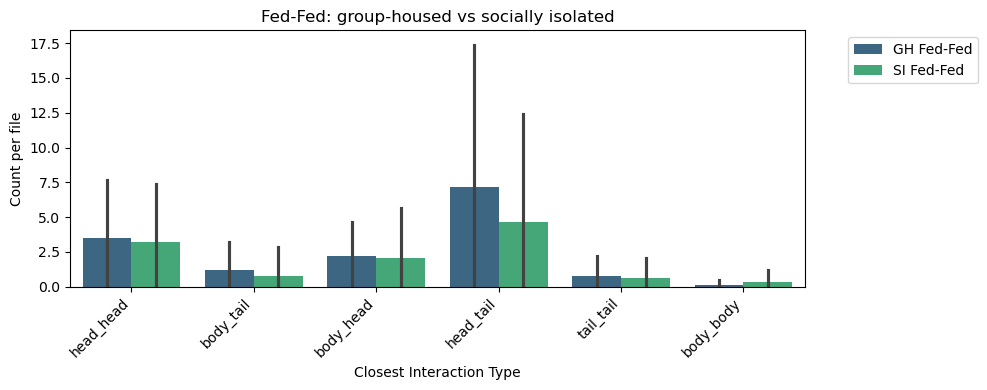

,Closest Interaction Type,condition_a,condition_b,test,p,p_adj,stars
5,body_body,GH Fed-Fed,SI Fed-Fed,Mann-Whitney U,0.347875,0.871308,n.s.
2,body_head,GH Fed-Fed,SI Fed-Fed,Mann-Whitney U,0.726090,0.871308,n.s.
1,body_tail,GH Fed-Fed,SI Fed-Fed,Mann-Whitney U,0.188082,0.871308,n.s.
0,head_head,GH Fed-Fed,SI Fed-Fed,Mann-Whitney U,0.885444,0.885444,n.s.
3,head_tail,GH Fed-Fed,SI Fed-Fed,Mann-Whitney U,0.502805,0.871308,n.s.
4,tail_tail,GH Fed-Fed,SI Fed-Fed,Mann-Whitney U,0.603088,0.871308,n.s.


In [10]:
fedfed_grouped, fedfed_pairwise, fedfed_omnibus = plot_contact_counts(
    [df1, df4],
    condition_order=['GH Fed-Fed', 'SI Fed-Fed'],
    palette='viridis',
    title='Fed-Fed: group-housed vs socially isolated'
)


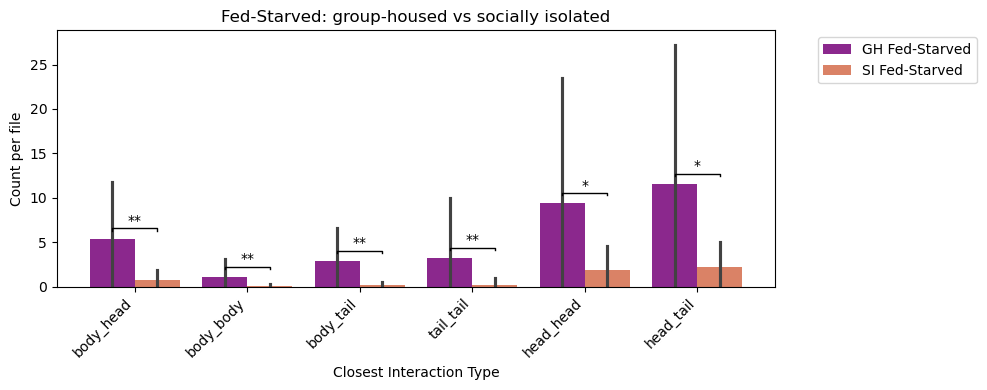

,Closest Interaction Type,condition_a,condition_b,test,p,p_adj,stars
1,body_body,GH Fed-Starved,SI Fed-Starved,Mann-Whitney U,0.002491,0.003737,**
0,body_head,GH Fed-Starved,SI Fed-Starved,Mann-Whitney U,0.001035,0.003104,**
2,body_tail,GH Fed-Starved,SI Fed-Starved,Mann-Whitney U,0.000361,0.002164,**
4,head_head,GH Fed-Starved,SI Fed-Starved,Mann-Whitney U,0.019286,0.019286,*
5,head_tail,GH Fed-Starved,SI Fed-Starved,Mann-Whitney U,0.016697,0.019286,*
3,tail_tail,GH Fed-Starved,SI Fed-Starved,Mann-Whitney U,0.002366,0.003737,**


In [11]:
fedstarved_grouped, fedstarved_pairwise, fedstarved_omnibus = plot_contact_counts(
    [df2, df5],
    condition_order=['GH Fed-Starved', 'SI Fed-Starved'],
    palette='plasma',
    title='Fed-Starved: group-housed vs socially isolated'
)


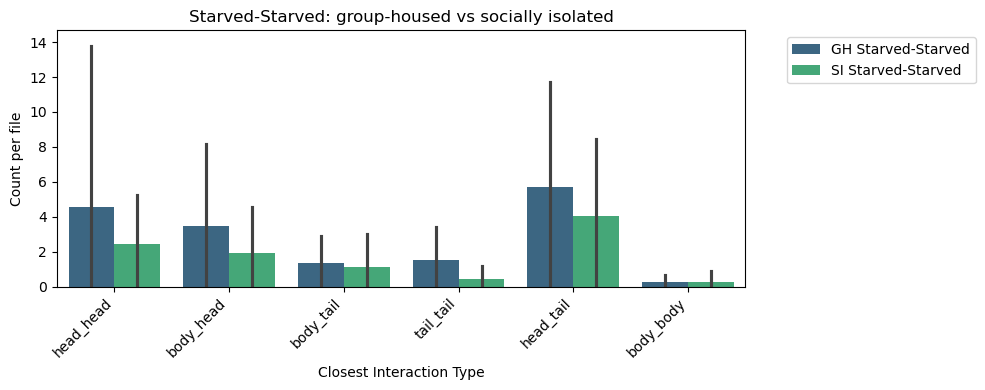

,Closest Interaction Type,condition_a,condition_b,test,p,p_adj,stars
5,body_body,GH Starved-Starved,SI Starved-Starved,Mann-Whitney U,0.631542,0.757850,n.s.
1,body_head,GH Starved-Starved,SI Starved-Starved,Mann-Whitney U,0.588875,0.757850,n.s.
2,body_tail,GH Starved-Starved,SI Starved-Starved,Mann-Whitney U,0.267112,0.757850,n.s.
0,head_head,GH Starved-Starved,SI Starved-Starved,Mann-Whitney U,0.965014,0.965014,n.s.
4,head_tail,GH Starved-Starved,SI Starved-Starved,Mann-Whitney U,0.597505,0.757850,n.s.
3,tail_tail,GH Starved-Starved,SI Starved-Starved,Mann-Whitney U,0.031706,0.190236,n.s.


In [12]:
starvedstarved_grouped, starvedstarved_pairwise, starvedstarved_omnibus = plot_contact_counts(
    [df3, df6],
    condition_order=['GH Starved-Starved', 'SI Starved-Starved'],
    palette='viridis',
    title='Starved-Starved: group-housed vs socially isolated'
)
